In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold'
})
sns.set_palette('Set2')
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [12]:
# Upload the CSV file
from google.colab import files
uploaded = files.upload()   # select: Most_runs_in_Indian_Premier_League.csv

Saving Most runs in Indian Premier League.csv to Most runs in Indian Premier League (1).csv


In [14]:
import os

# Auto-find the uploaded CSV file
uploaded_files = [f for f in os.listdir('/content') if f.endswith('.csv')]
print("Found files:", uploaded_files)

df = pd.read_csv(f'/content/{uploaded_files[0]}', index_col=0)
print(f'Shape: {df.shape}')
df.head()

Found files: ['Most runs in Indian Premier League (1).csv']
Shape: (150, 16)


,player,span,playing_team,matches,innings,not_out,runs,strike_rate,average,balls_faced,highest_score,hundreds,fifties,ducks,fours,sixes
0,V Kohli (RCB),2008-2025,RCB,267,259,40.0,8661,132.85,39.54,6519,113*,8.0,63.0,10.0,771,291
1,RG Sharma (DCH/MI),2008-2025,DCH/MI,272,267,30.0,7046,132.09,29.73,5334,109*,2.0,47.0,18.0,640,302
2,S Dhawan (DC/DCH/MI/PBKS/SRH),2008-2024,DC/DCH/MI/PBKS/SRH,222,221,29.0,6769,127.14,35.25,5324,106*,2.0,51.0,11.0,768,152
3,DA Warner (DC/SRH),2009-2024,DC/SRH,184,184,22.0,6565,139.77,40.52,4697,126,4.0,62.0,11.0,663,236
4,SK Raina (CSK/GL),2008-2021,CSK/GL,205,200,30.0,5528,136.73,32.51,4043,100*,1.0,39.0,8.0,506,203


In [15]:
# ── Basic info ────────────────────────────────────────────────────
print('Columns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Columns: ['player', 'span', 'playing_team', 'matches', 'innings', 'not_out', 'runs', 'strike_rate', 'average', 'balls_faced', 'highest_score', 'hundreds', 'fifties', 'ducks', 'fours', 'sixes']

Missing values:
player            0
span              0
playing_team      0
matches           0
innings           0
not_out           2
runs              0
strike_rate       0
average           0
balls_faced       0
highest_score     0
hundreds         97
fifties           7
ducks             6
fours             0
sixes             0
dtype: int64

Data types:
player            object
span              object
playing_team      object
matches            int64
innings            int64
not_out          float64
runs               int64
strike_rate      float64
average          float64
balls_faced        int64
highest_score     object
hundreds         float64
fifties          float64
ducks            float64
fours              int64
sixes              int64
dtype: object


In [16]:
# ── Fill missing values ────────────────────────────────────────────
df['hundreds'] = df['hundreds'].fillna(0).astype(int)
df['fifties']  = df['fifties'].fillna(0).astype(int)
df['ducks']    = df['ducks'].fillna(0).astype(int)

# ── Extract first name / short name ───────────────────────────────
df['short_name'] = df['player'].str.split('(').str[0].str.strip()

# ── Career span length ────────────────────────────────────────────
df['start_year'] = df['span'].str.split('-').str[0].astype(int)
df['end_year']   = df['span'].str.split('-').str[1].astype(int)
df['career_years'] = df['end_year'] - df['start_year'] + 1

# ── Derived stats ─────────────────────────────────────────────────
df['dismissals']       = df['innings'] - df['not_out']
df['boundary_runs']    = (df['fours'] * 4) + (df['sixes'] * 6)
df['boundary_run_pct'] = (df['boundary_runs'] / df['runs'] * 100).round(1)
df['runs_per_match']   = (df['runs'] / df['matches']).round(2)
df['dot_ball_estimate']= (df['balls_faced'] - df['fours'] - df['sixes']).clip(lower=0)

print('✅ Cleaning complete! Rows:', len(df))
df[['short_name','runs','average','strike_rate','career_years','boundary_run_pct']].head(10)

✅ Cleaning complete! Rows: 150


,short_name,runs,average,strike_rate,career_years,boundary_run_pct
0,V Kohli,8661,39.54,132.85,18,55.8
1,RG Sharma,7046,29.73,132.09,18,62.0
2,S Dhawan,6769,35.25,127.14,17,58.9
3,DA Warner,6565,40.52,139.77,16,62.0
4,SK Raina,5528,32.51,136.73,14,58.6
5,MS Dhoni,5439,38.30,137.45,18,56.7
6,KL Rahul,5222,46.21,136.02,13,58.5
7,AB de Villiers,5162,39.70,151.68,14,61.2
8,AM Rahane,5032,30.49,125.01,18,55.5
9,CH Gayle,4965,39.72,148.96,13,75.7


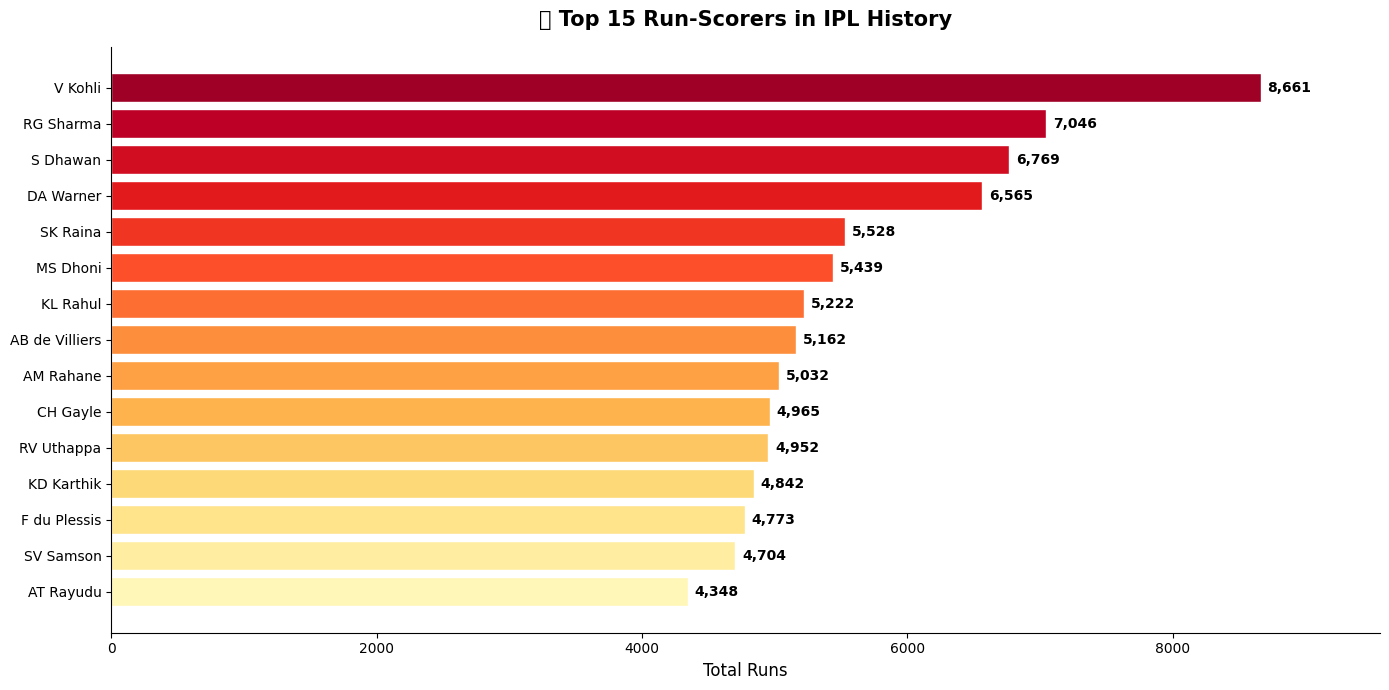


👑 All-time leader: V Kohli with 8,661 runs


In [17]:
top15 = df.nlargest(15, 'runs')

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('YlOrRd_r', 15)
bars = ax.barh(top15['short_name'][::-1], top15['runs'][::-1], color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top15['runs'][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('🏆 Top 15 Run-Scorers in IPL History', pad=15)
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, top15['runs'].max() + 900)
plt.tight_layout()
plt.show()

print(f'\n👑 All-time leader: {df.iloc[0]["short_name"]} with {df.iloc[0]["runs"]:,} runs')

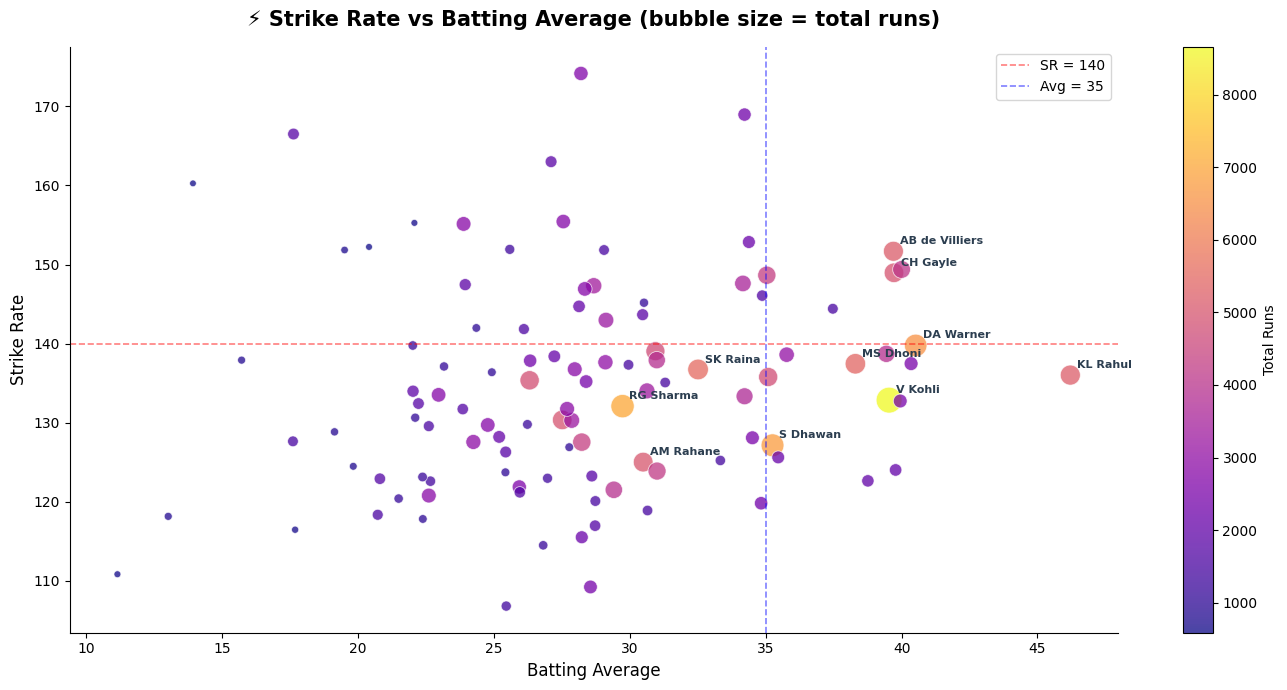

In [18]:
# Filter players with significant innings
qualified = df[df['innings'] >= 50].copy()

fig, ax = plt.subplots(figsize=(14, 7))

scatter = ax.scatter(
    qualified['average'],
    qualified['strike_rate'],
    s=qualified['runs'] / 25,        # bubble size = runs
    c=qualified['runs'],
    cmap='plasma',
    alpha=0.75,
    edgecolors='white',
    linewidth=0.6
)

# Reference lines
ax.axhline(140, linestyle='--', color='red',   alpha=0.5, linewidth=1.2, label='SR = 140')
ax.axvline(35,  linestyle='--', color='blue',  alpha=0.5, linewidth=1.2, label='Avg = 35')

# Annotate top players
top_ann = qualified.nlargest(10, 'runs')
for _, row in top_ann.iterrows():
    ax.annotate(row['short_name'],
                (row['average'], row['strike_rate']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold', color='#2c3e50')

plt.colorbar(scatter, ax=ax, label='Total Runs')
ax.set_title('⚡ Strike Rate vs Batting Average (bubble size = total runs)', pad=15)
ax.set_xlabel('Batting Average', fontsize=12)
ax.set_ylabel('Strike Rate', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
# ── Quadrant classification ───────────────────────────────────────
avg_thresh = qualified['average'].median()
sr_thresh  = qualified['strike_rate'].median()

def classify(row):
    if row['average'] >= avg_thresh and row['strike_rate'] >= sr_thresh:
        return '🔥 Elite (High Avg + High SR)'
    elif row['average'] >= avg_thresh:
        return '🛡️ Anchor (High Avg, Low SR)'
    elif row['strike_rate'] >= sr_thresh:
        return '💥 Aggressor (Low Avg, High SR)'
    else:
        return '🔄 Rebuilder (Low Avg + Low SR)'

qualified['type'] = qualified.apply(classify, axis=1)
print('Player Quadrant Classification:')
print(qualified[['short_name','average','strike_rate','type']].sort_values('type').to_string(index=False))

Player Quadrant Classification:
       short_name  average  strike_rate                           type
      Rashid Khan    13.92       160.27 💥 Aggressor (Low Avg, High SR)
       MA Agarwal    22.96       133.52 💥 Aggressor (Low Avg, High SR)
         V Sehwag    27.55       155.44 💥 Aggressor (Low Avg, High SR)
        SM Curran    24.92       136.38 💥 Aggressor (Low Avg, High SR)
      RA Tripathi    26.33       137.84 💥 Aggressor (Low Avg, High SR)
     AC Gilchrist    27.22       138.39 💥 Aggressor (Low Avg, High SR)
       PJ Cummins    20.40       152.23 💥 Aggressor (Low Avg, High SR)
       GJ Maxwell    23.88       155.14 💥 Aggressor (Low Avg, High SR)
         AR Patel    22.02       133.98 💥 Aggressor (Low Avg, High SR)
  Abhishek Sharma    27.10       163.01 💥 Aggressor (Low Avg, High SR)
        SP Narine    17.62       166.51 💥 Aggressor (Low Avg, High SR)
        R Tewatia    23.16       137.11 💥 Aggressor (Low Avg, High SR)
          R Parag    26.10       141.84 💥 Agg

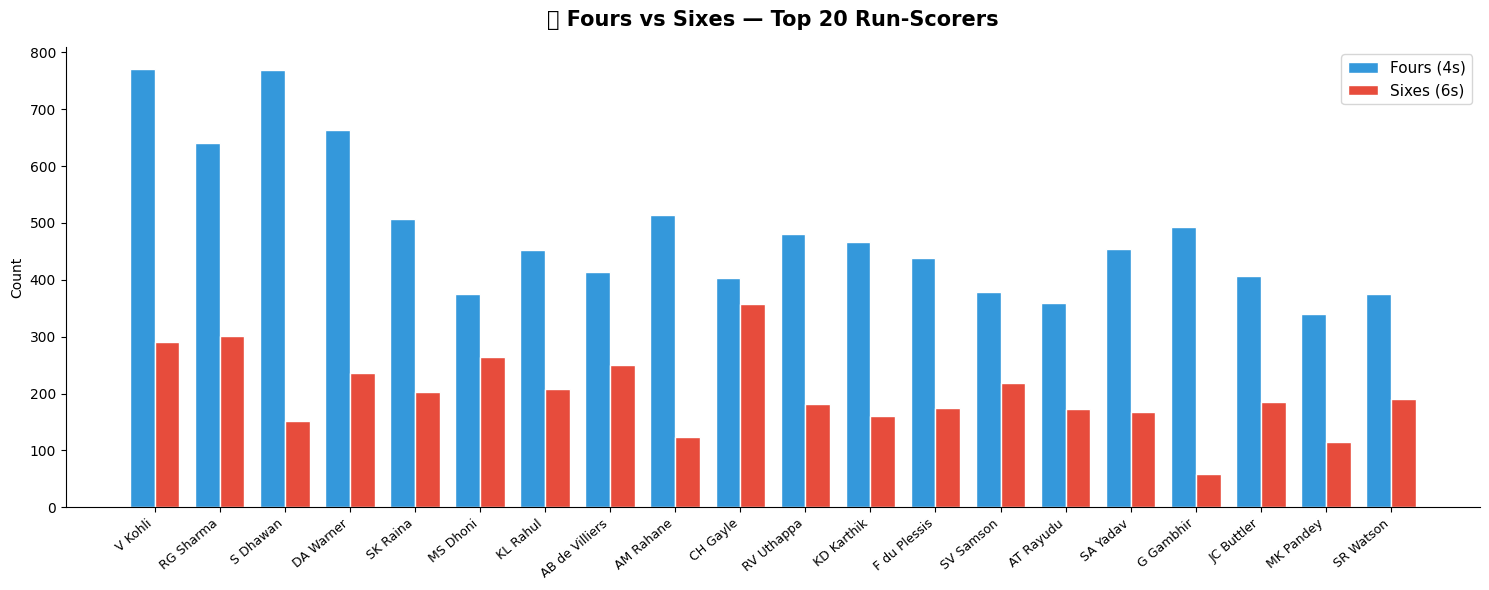

In [20]:
top20 = df.nlargest(20, 'runs')[['short_name','fours','sixes']]

x = np.arange(len(top20))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x - width/2, top20['fours'], width, label='Fours (4s)', color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, top20['sixes'], width, label='Sixes (6s)', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top20['short_name'], rotation=40, ha='right', fontsize=9)
ax.set_title('🎯 Fours vs Sixes — Top 20 Run-Scorers', pad=15)
ax.set_ylabel('Count')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

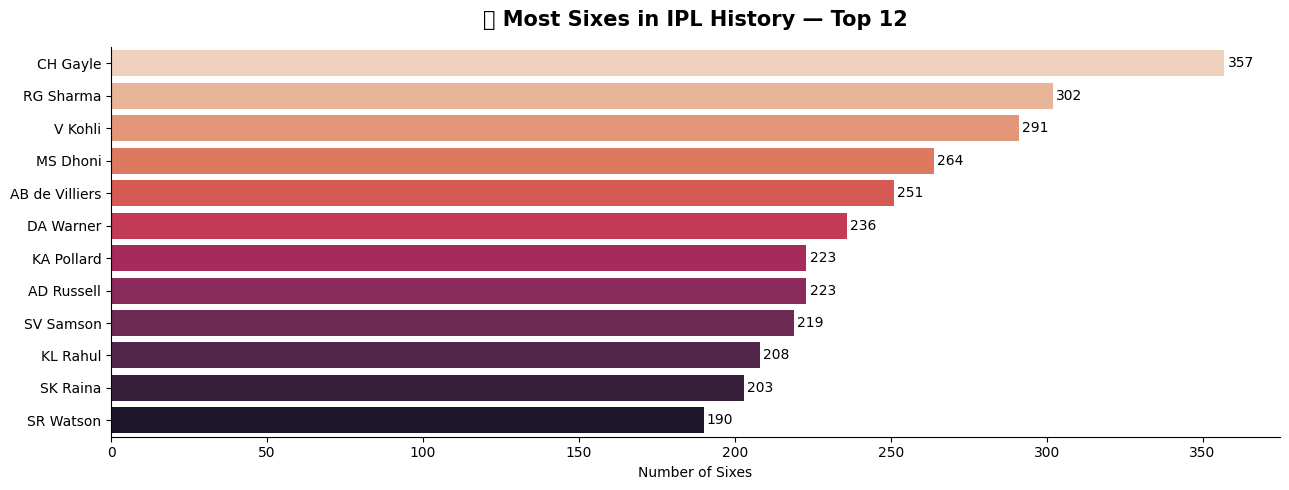

In [21]:
# ── Six-hitters leaderboard ───────────────────────────────────────
top_sixes = df.nlargest(12, 'sixes')[['short_name','sixes','fours']]

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=top_sixes, x='sixes', y='short_name', palette='rocket_r', ax=ax)
ax.set_title('💥 Most Sixes in IPL History — Top 12', pad=15)
ax.set_xlabel('Number of Sixes')
ax.set_ylabel('')
for p in ax.patches:
    ax.text(p.get_width() + 1, p.get_y() + p.get_height()/2,
            str(int(p.get_width())), va='center', fontsize=10)
plt.tight_layout()
plt.show()

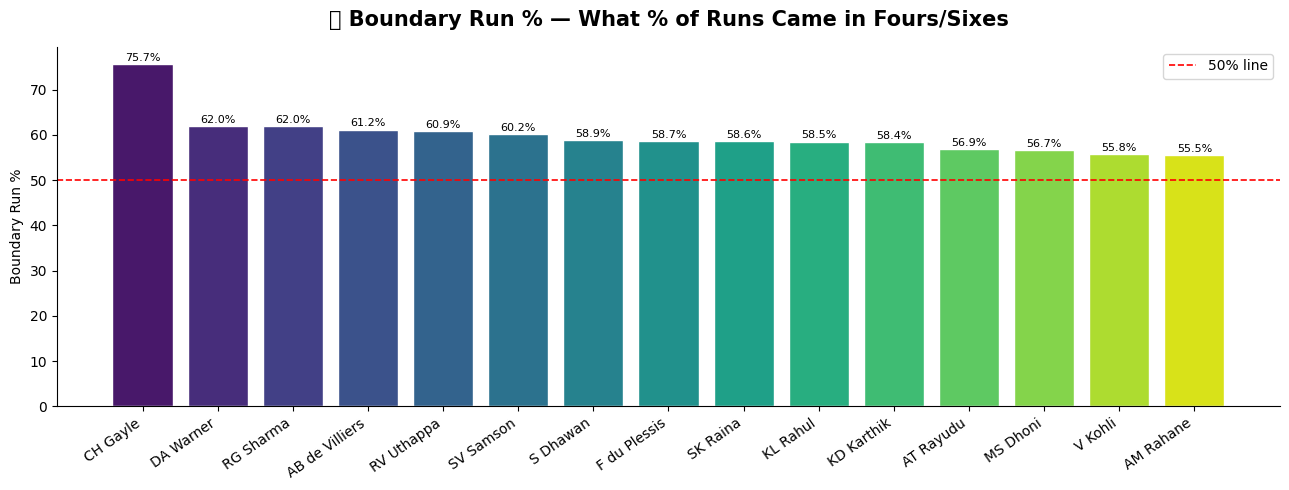

In [22]:
# ── Boundary run % (how much of their runs came in boundaries) ─────
top_bpct = df.nlargest(15, 'runs')[['short_name','boundary_run_pct','runs']].sort_values('boundary_run_pct', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(top_bpct['short_name'], top_bpct['boundary_run_pct'],
              color=sns.color_palette('viridis', len(top_bpct)), edgecolor='white')
ax.axhline(50, linestyle='--', color='red', linewidth=1.2, label='50% line')
ax.set_title('📊 Boundary Run % — What % of Runs Came in Fours/Sixes', pad=15)
ax.set_ylabel('Boundary Run %')
ax.set_xticklabels(top_bpct['short_name'], rotation=35, ha='right')
ax.legend()
for bar, val in zip(bars, top_bpct['boundary_run_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

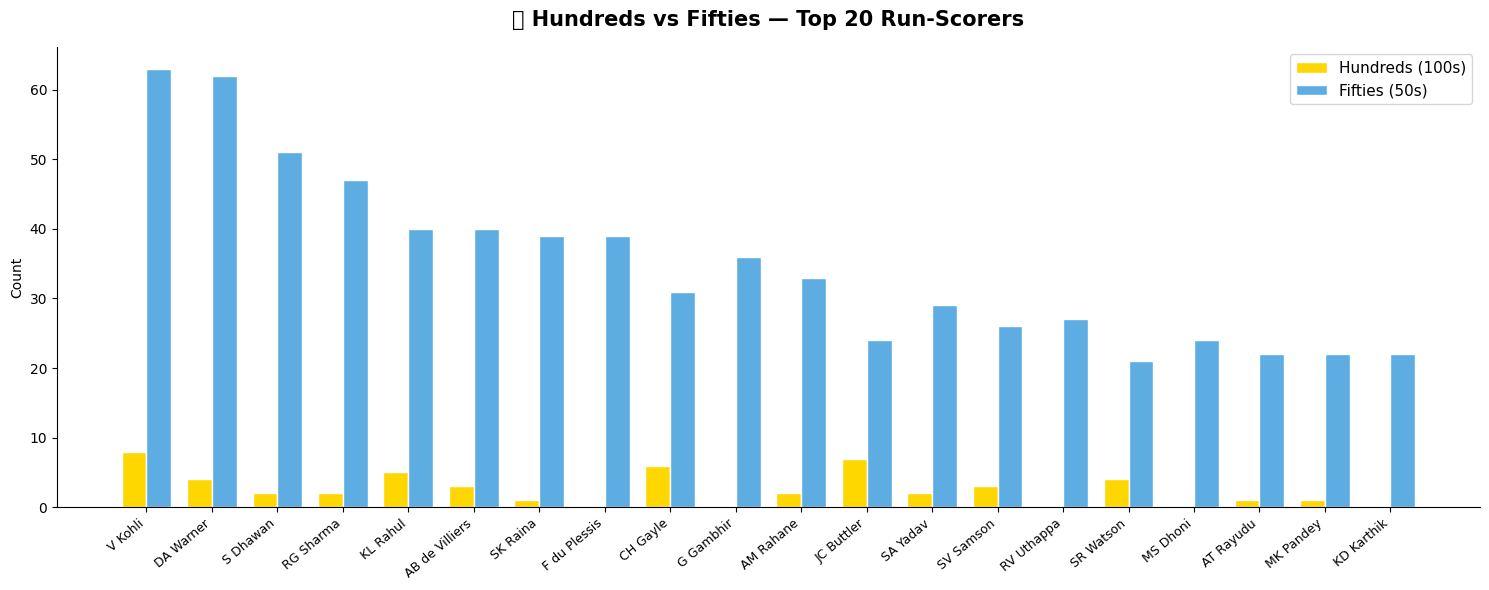

In [23]:
# Top players by combined hundreds + fifties
milestones = df.nlargest(20, 'runs')[['short_name','hundreds','fifties']].copy()
milestones['total'] = milestones['hundreds'] + milestones['fifties']
milestones = milestones.sort_values('total', ascending=False)

x = np.arange(len(milestones))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width/2, milestones['hundreds'], width, label='Hundreds (100s)', color='gold', edgecolor='white')
ax.bar(x + width/2, milestones['fifties'],  width, label='Fifties (50s)',   color='#5dade2', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(milestones['short_name'], rotation=40, ha='right', fontsize=9)
ax.set_title('💯 Hundreds vs Fifties — Top 20 Run-Scorers', pad=15)
ax.set_ylabel('Count')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

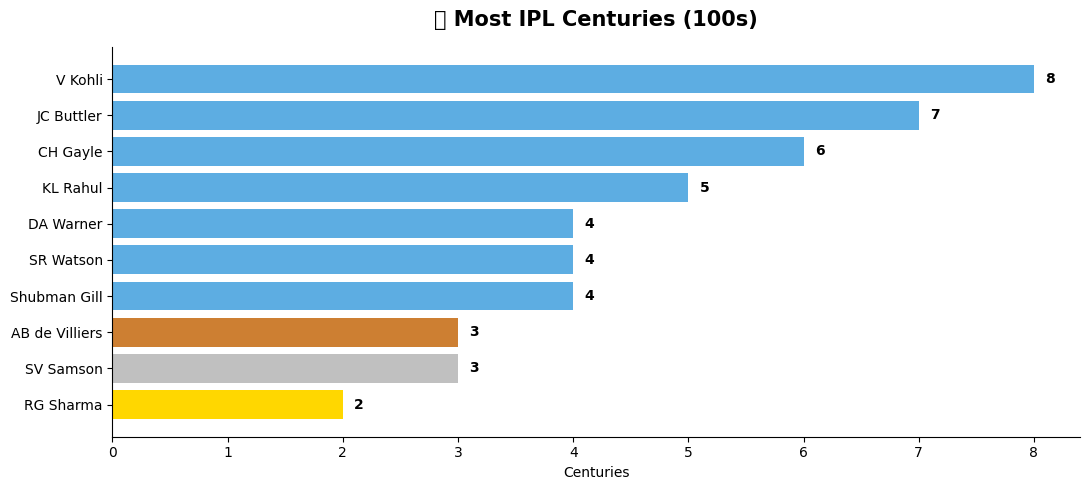

In [24]:
# ── Most hundreds in IPL ──────────────────────────────────────────
top_tons = df.nlargest(10, 'hundreds')[['short_name','hundreds','runs']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_tons['short_name'][::-1], top_tons['hundreds'][::-1],
               color=['gold','silver','#cd7f32'] + ['#5dade2']*7)
ax.set_title('🥇 Most IPL Centuries (100s)', pad=15)
ax.set_xlabel('Centuries')
ax.set_ylabel('')
for bar, val in zip(bars, top_tons['hundreds'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

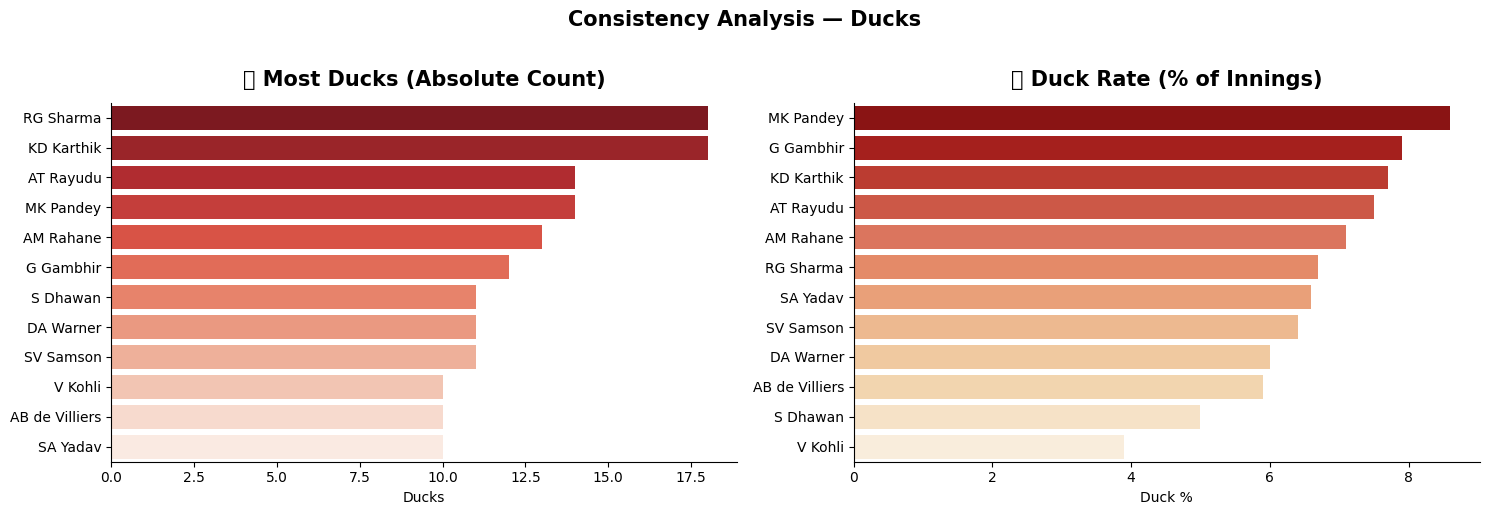

In [25]:
# Most ducks among top run-scorers
ducks_df = df.nlargest(30, 'runs').nlargest(12, 'ducks')[['short_name','ducks','innings']]
ducks_df['duck_pct'] = (ducks_df['ducks'] / ducks_df['innings'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute ducks
sns.barplot(data=ducks_df.sort_values('ducks', ascending=False),
            x='ducks', y='short_name', palette='Reds_r', ax=axes[0])
axes[0].set_title('🦆 Most Ducks (Absolute Count)', pad=12)
axes[0].set_xlabel('Ducks')
axes[0].set_ylabel('')

# Duck %
sns.barplot(data=ducks_df.sort_values('duck_pct', ascending=False),
            x='duck_pct', y='short_name', palette='OrRd_r', ax=axes[1])
axes[1].set_title('🦆 Duck Rate (% of Innings)', pad=12)
axes[1].set_xlabel('Duck %')
axes[1].set_ylabel('')

plt.suptitle('Consistency Analysis — Ducks', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

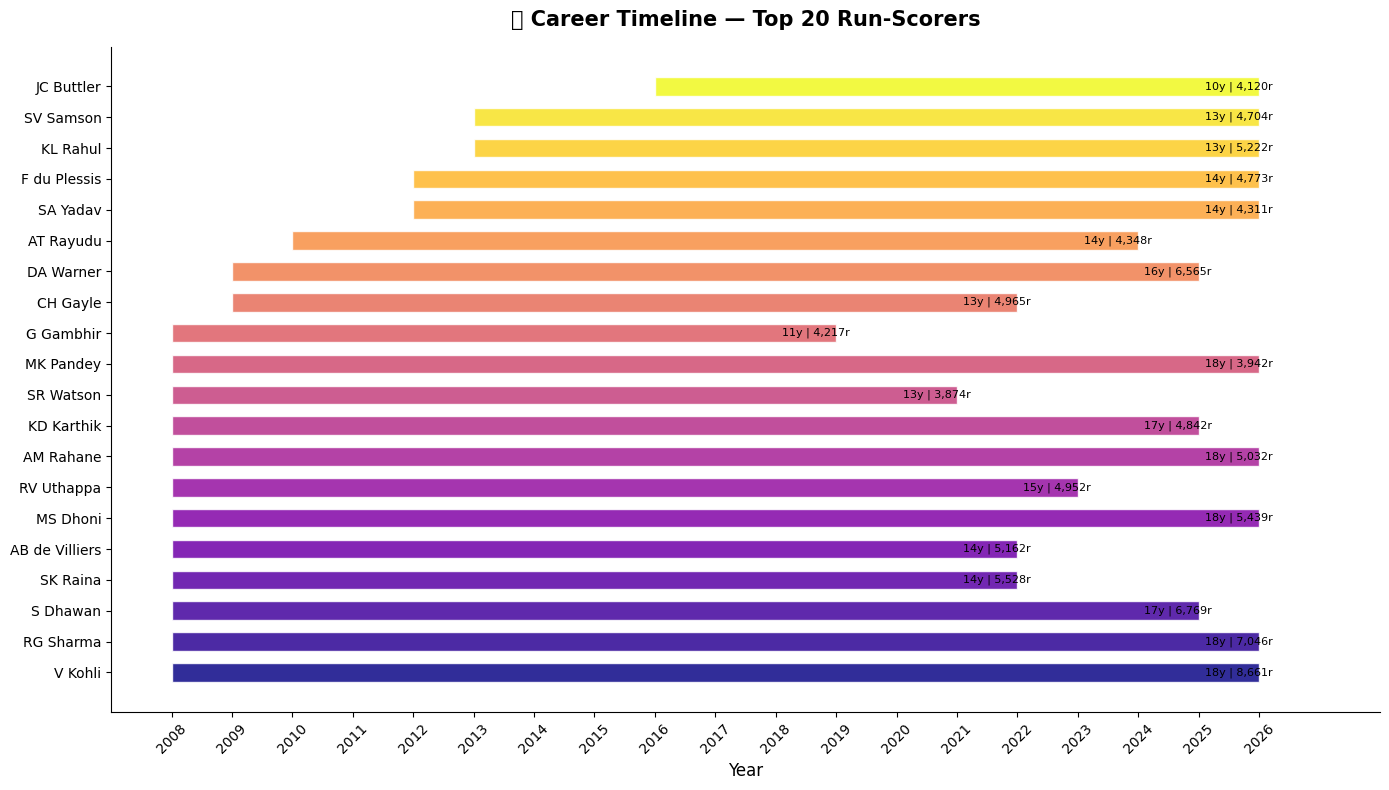

In [26]:
# Gantt-style career timeline for top 20 players
top20_span = df.nlargest(20, 'runs')[['short_name','start_year','end_year','career_years','runs']].copy()
top20_span = top20_span.sort_values('start_year')

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.cm.get_cmap('plasma', len(top20_span))

for i, (_, row) in enumerate(top20_span.iterrows()):
    ax.barh(row['short_name'],
            row['career_years'],
            left=row['start_year'],
            color=cmap(i), alpha=0.85, edgecolor='white', height=0.6)
    ax.text(row['end_year'] + 0.1, row['short_name'],
            f"{row['career_years']}y | {row['runs']:,}r",
            va='center', fontsize=8)

ax.set_xlabel('Year', fontsize=12)
ax.set_title('📅 Career Timeline — Top 20 Run-Scorers', pad=15)
ax.set_xlim(2007, 2028)
ax.set_xticks(range(2008, 2027))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

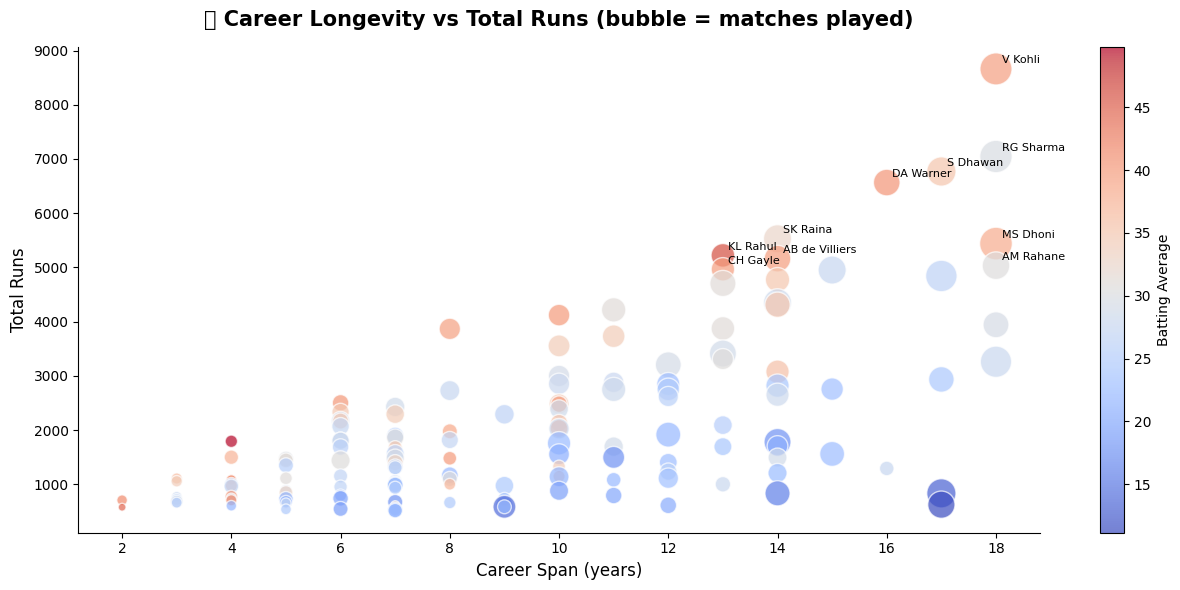

In [27]:
# Longevity vs total runs
fig, ax = plt.subplots(figsize=(13, 6))
scatter = ax.scatter(
    df['career_years'], df['runs'],
    s=df['matches'] * 2,
    c=df['average'],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='white'
)
plt.colorbar(scatter, ax=ax, label='Batting Average')

# Annotate top 10
for _, row in df.nlargest(10, 'runs').iterrows():
    ax.annotate(row['short_name'],
                (row['career_years'], row['runs']),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_title('📅 Career Longevity vs Total Runs (bubble = matches played)', pad=15)
ax.set_xlabel('Career Span (years)', fontsize=12)
ax.set_ylabel('Total Runs', fontsize=12)
plt.tight_layout()
plt.show()

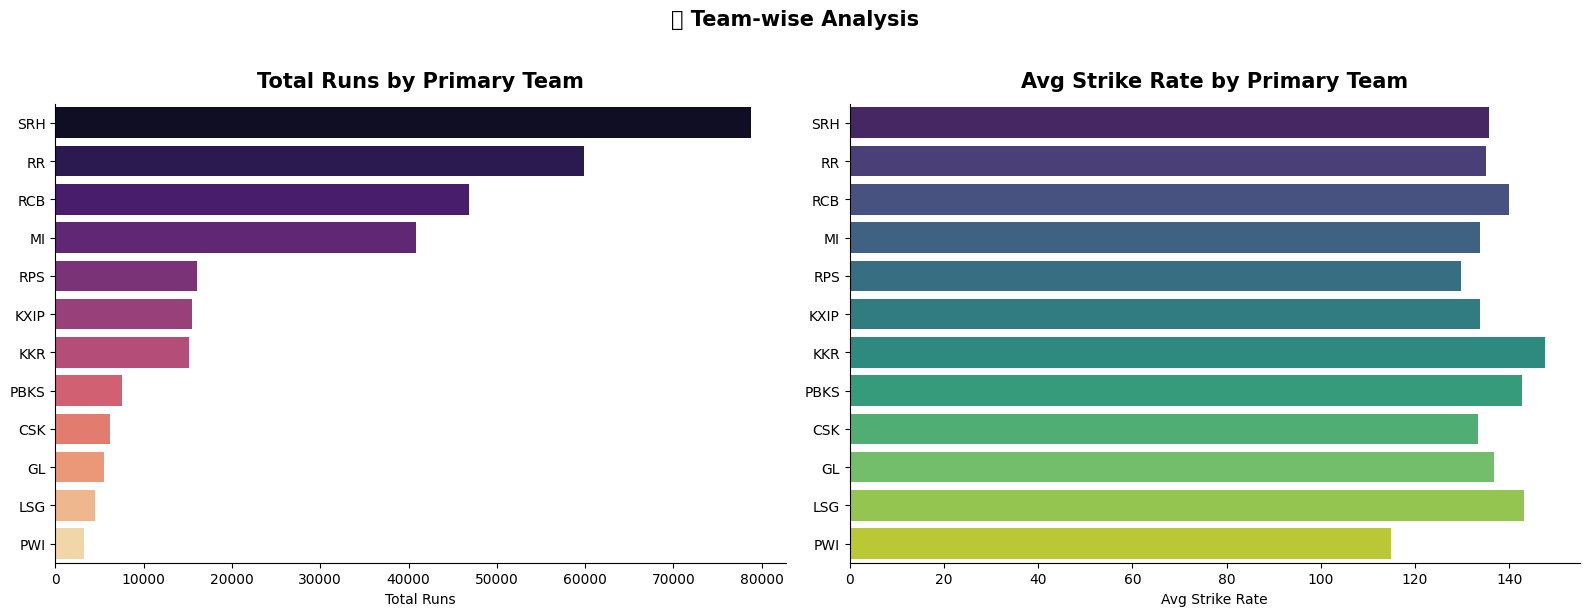

In [28]:
# Each player may have played for multiple teams — expand to primary team
# We use the LAST team listed (most recent) as primary
df['primary_team'] = df['playing_team'].str.split('/').str[-1].str.strip()

team_runs = df.groupby('primary_team').agg(
    total_runs=('runs','sum'),
    players=('short_name','count'),
    avg_sr=('strike_rate','mean')
).reset_index().sort_values('total_runs', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total runs
sns.barplot(data=team_runs.head(12), x='total_runs', y='primary_team',
            palette='magma', ax=axes[0])
axes[0].set_title('Total Runs by Primary Team', pad=12)
axes[0].set_xlabel('Total Runs')
axes[0].set_ylabel('')

# Avg strike rate
sns.barplot(data=team_runs.head(12), x='avg_sr', y='primary_team',
            palette='viridis', ax=axes[1])
axes[1].set_title('Avg Strike Rate by Primary Team', pad=12)
axes[1].set_xlabel('Avg Strike Rate')
axes[1].set_ylabel('')

plt.suptitle('🏟️ Team-wise Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

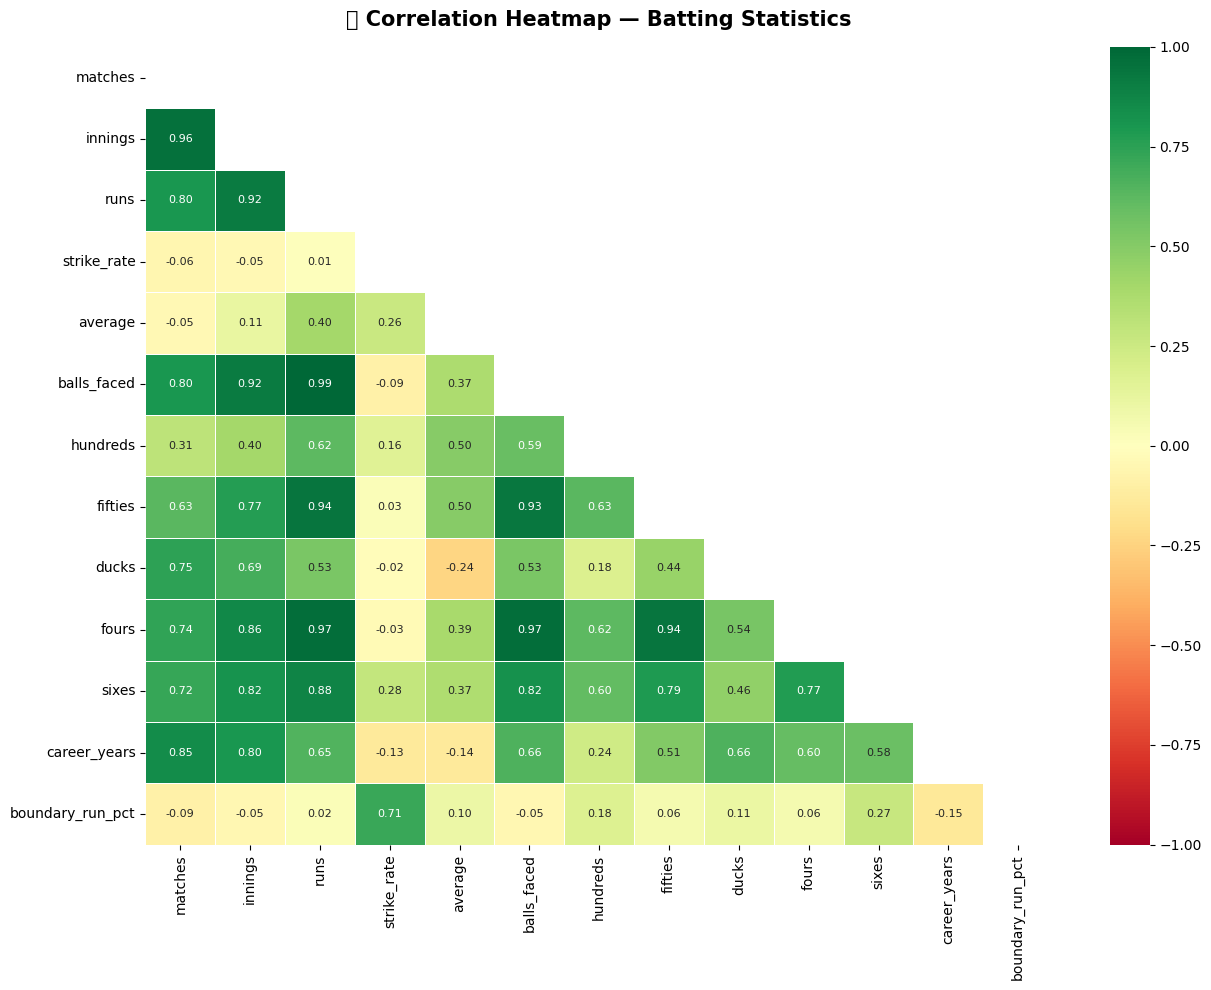

In [29]:
corr_cols = ['matches','innings','runs','strike_rate','average',
             'balls_faced','hundreds','fifties','ducks','fours','sixes',
             'career_years','boundary_run_pct']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})
ax.set_title('🔥 Correlation Heatmap — Batting Statistics', pad=15)
plt.tight_layout()
plt.show()

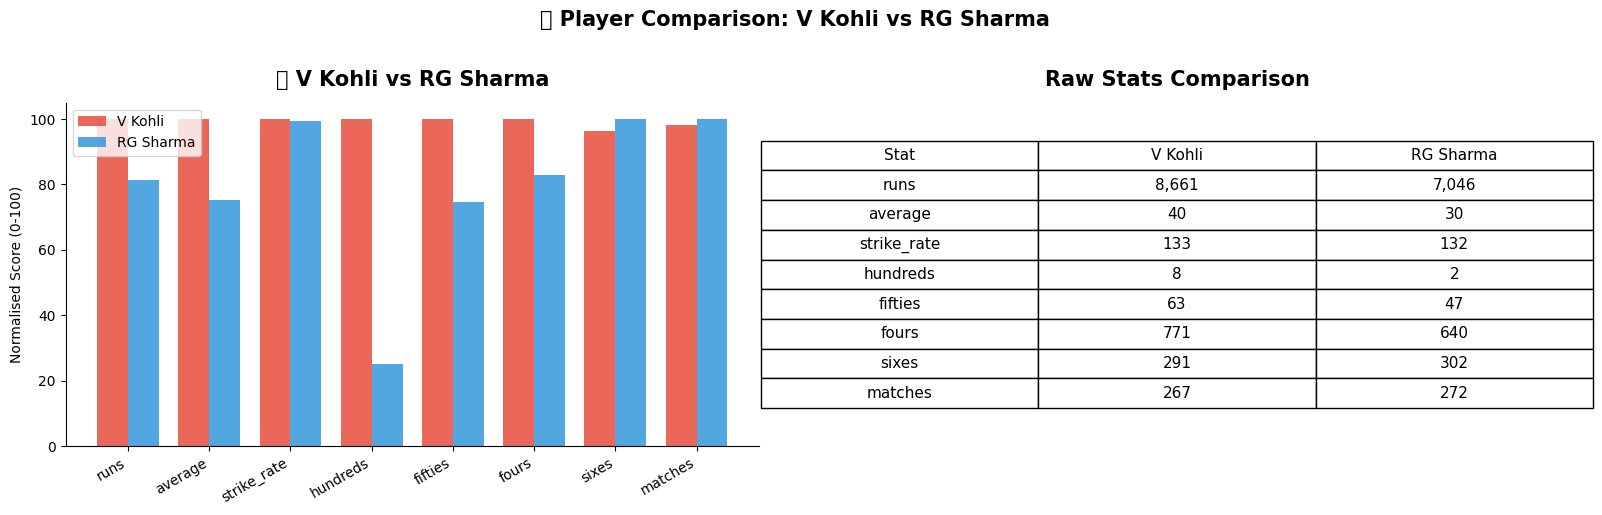

In [30]:
# ── Change players here ───────────────────────────────────────────
PLAYER_1 = 'V Kohli'         # first part of the name
PLAYER_2 = 'RG Sharma'
# ─────────────────────────────────────────────────────────────────

p1 = df[df['short_name'].str.contains(PLAYER_1, case=False)].iloc[0]
p2 = df[df['short_name'].str.contains(PLAYER_2, case=False)].iloc[0]

stats = ['runs','average','strike_rate','hundreds','fifties','fours','sixes','matches']

p1_vals = [float(p1[s]) for s in stats]
p2_vals = [float(p2[s]) for s in stats]

# Normalize each stat to 0-100 for radar
combined_max = [max(a, b) for a, b in zip(p1_vals, p2_vals)]
p1_norm = [v/m*100 if m > 0 else 0 for v, m in zip(p1_vals, combined_max)]
p2_norm = [v/m*100 if m > 0 else 0 for v, m in zip(p2_vals, combined_max)]

# Side-by-side bar comparison
x = np.arange(len(stats))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x - width/2, p1_norm, width, label=p1['short_name'], color='#e74c3c', alpha=0.85)
axes[0].bar(x + width/2, p2_norm, width, label=p2['short_name'], color='#3498db', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(stats, rotation=30, ha='right')
axes[0].set_ylabel('Normalised Score (0-100)')
axes[0].set_title(f'📊 {PLAYER_1} vs {PLAYER_2}', pad=12)
axes[0].legend()

# Table
table_data = [[s, f'{v1:,.0f}', f'{v2:,.0f}'] for s, v1, v2 in zip(stats, p1_vals, p2_vals)]
col_labels = ['Stat', p1['short_name'], p2['short_name']]
table = axes[1].table(cellText=table_data, colLabels=col_labels,
                      loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
axes[1].axis('off')
axes[1].set_title('Raw Stats Comparison', pad=12)

plt.suptitle(f'🤝 Player Comparison: {PLAYER_1} vs {PLAYER_2}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

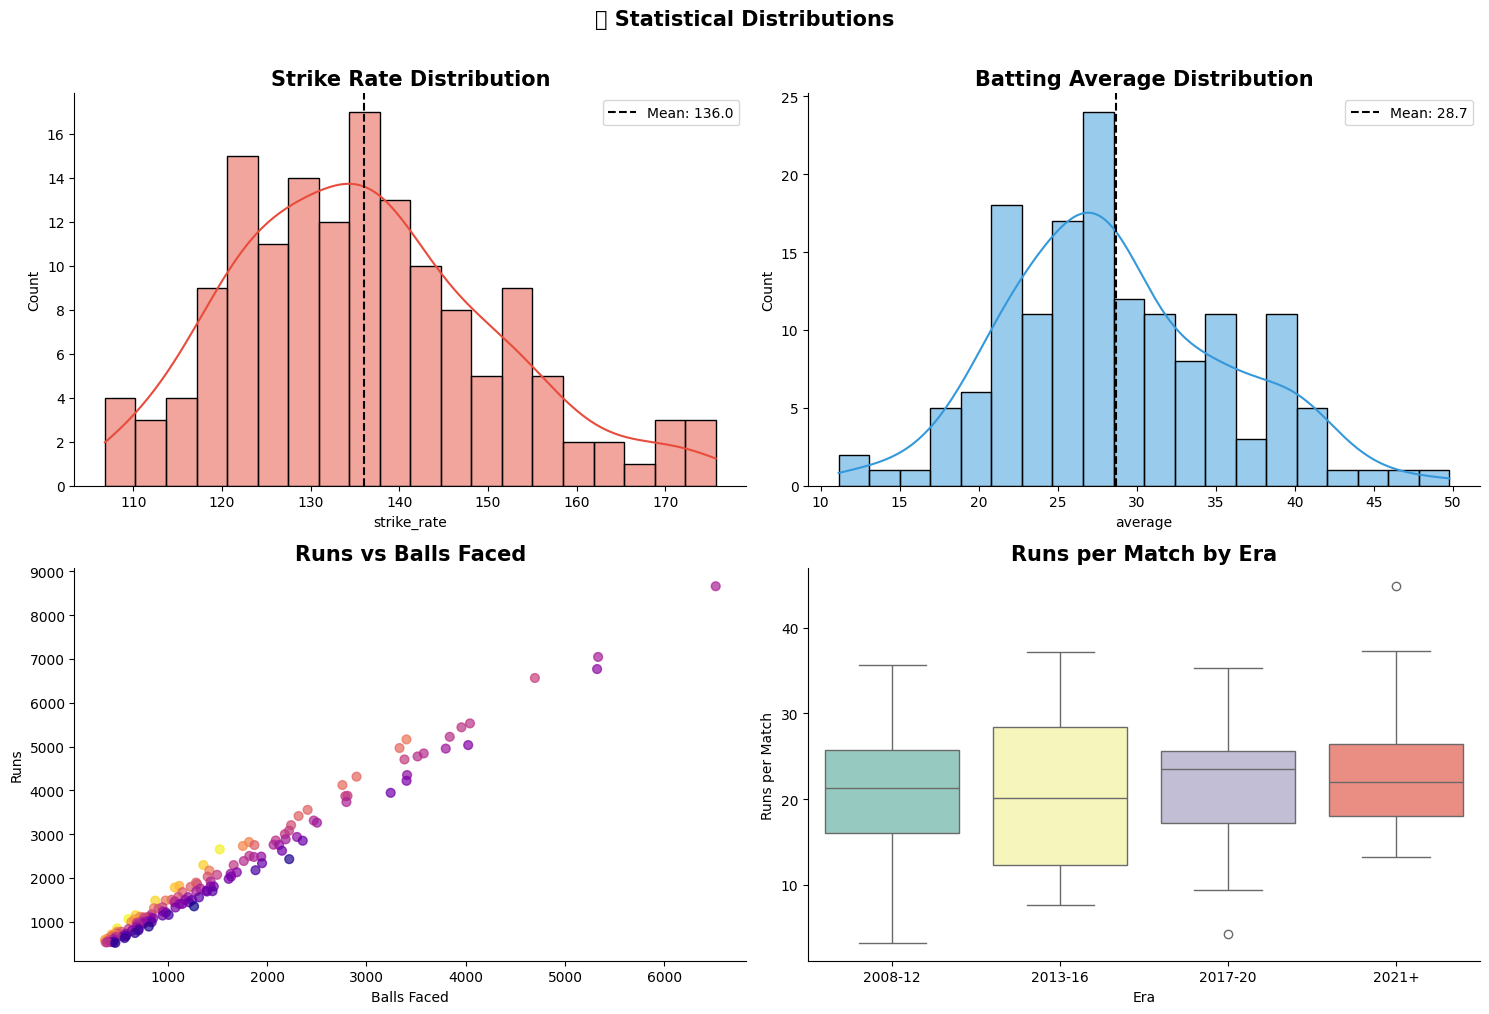

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Strike Rate distribution
sns.histplot(df['strike_rate'], bins=20, kde=True, ax=axes[0,0], color='#e74c3c')
axes[0,0].axvline(df['strike_rate'].mean(), color='black', linestyle='--',
                   label=f'Mean: {df["strike_rate"].mean():.1f}')
axes[0,0].set_title('Strike Rate Distribution')
axes[0,0].legend()

# Average distribution
sns.histplot(df['average'], bins=20, kde=True, ax=axes[0,1], color='#3498db')
axes[0,1].axvline(df['average'].mean(), color='black', linestyle='--',
                   label=f'Mean: {df["average"].mean():.1f}')
axes[0,1].set_title('Batting Average Distribution')
axes[0,1].legend()

# Runs vs balls faced
axes[1,0].scatter(df['balls_faced'], df['runs'], c=df['strike_rate'],
                  cmap='plasma', alpha=0.7, s=40)
axes[1,0].set_title('Runs vs Balls Faced')
axes[1,0].set_xlabel('Balls Faced')
axes[1,0].set_ylabel('Runs')

# Runs per match boxplot by era
df['era'] = pd.cut(df['start_year'], bins=[2007,2012,2016,2020,2026],
                    labels=['2008-12','2013-16','2017-20','2021+'])
sns.boxplot(data=df, x='era', y='runs_per_match', palette='Set3', ax=axes[1,1])
axes[1,1].set_title('Runs per Match by Era')
axes[1,1].set_xlabel('Era')
axes[1,1].set_ylabel('Runs per Match')

plt.suptitle('📊 Statistical Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

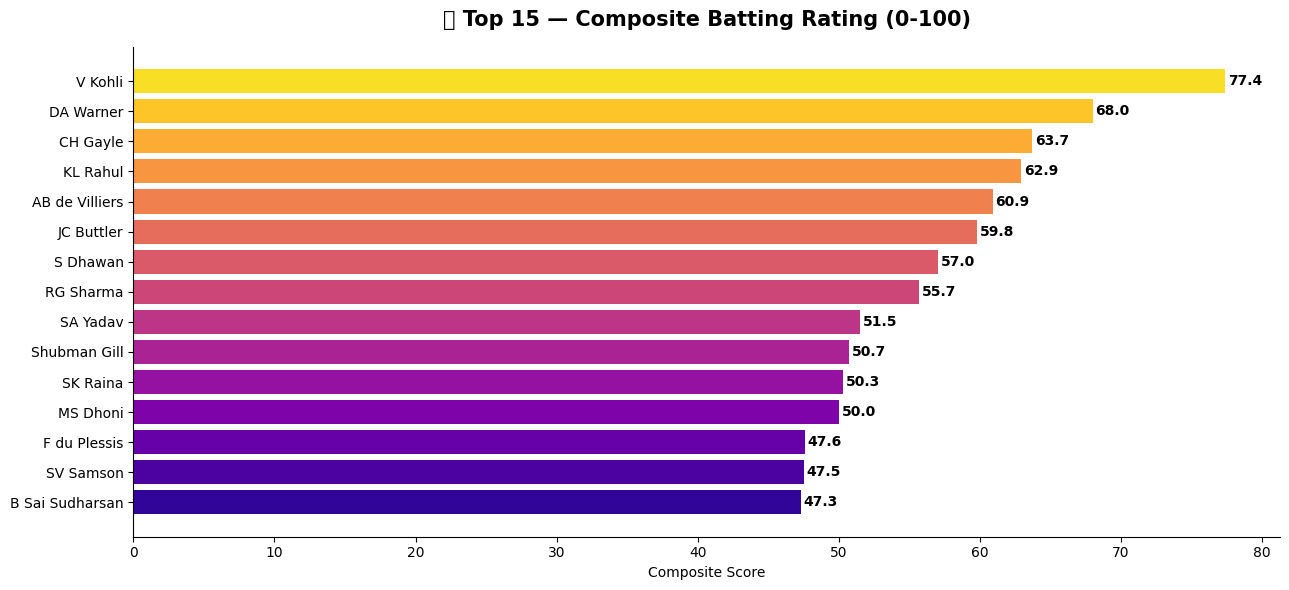


Top 15 Players — Full Rating Table:
     short_name  composite_score  runs  average  strike_rate
        V Kohli             77.4  8661    39.54       132.85
      DA Warner             68.0  6565    40.52       139.77
       CH Gayle             63.7  4965    39.72       148.96
       KL Rahul             62.9  5222    46.21       136.02
 AB de Villiers             60.9  5162    39.70       151.68
     JC Buttler             59.8  4120    40.00       149.38
       S Dhawan             57.0  6769    35.25       127.14
      RG Sharma             55.7  7046    29.73       132.09
       SA Yadav             51.5  4311    35.04       148.65
   Shubman Gill             50.7  3866    39.44       138.71
       SK Raina             50.3  5528    32.51       136.73
       MS Dhoni             50.0  5439    38.30       137.45
   F du Plessis             47.6  4773    35.09       135.78
      SV Samson             47.5  4704    30.94       139.04
B Sai Sudharsan             47.3  1793    49.80 

In [32]:
# Composite batting score (normalised)
from sklearn.preprocessing import MinMaxScaler

score_cols = ['runs','average','strike_rate','hundreds','fifties','boundary_run_pct']
df_score = df[score_cols].fillna(0).copy()

scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_score), columns=score_cols)

# Weighted composite
weights = {'runs': 0.30, 'average': 0.25, 'strike_rate': 0.20,
           'hundreds': 0.10, 'fifties': 0.10, 'boundary_run_pct': 0.05}
df['composite_score'] = sum(df_norm[col] * w for col, w in weights.items())
df['composite_score'] = (df['composite_score'] * 100).round(1)

top_rated = df.nlargest(15, 'composite_score')[['short_name','composite_score','runs','average','strike_rate']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_rated['short_name'][::-1],
               top_rated['composite_score'][::-1],
               color=sns.color_palette('plasma', 15))
ax.set_title('🏅 Top 15 — Composite Batting Rating (0-100)', pad=15)
ax.set_xlabel('Composite Score')
ax.set_ylabel('')
for bar, val in zip(bars, top_rated['composite_score'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 15 Players — Full Rating Table:')
print(top_rated.to_string(index=False))

In [33]:
print('=' * 65)
print('        🏏  IPL MOST RUNS — KEY INSIGHTS')
print('=' * 65)
print(f'\n📋 Total players in dataset  : {len(df)}')
print(f'📅 Seasons covered           : {df["start_year"].min()} – {df["end_year"].max()}')

top = df.iloc[0]
print(f'\n🏆 Most runs                 : {top["short_name"]} — {top["runs"]:,} runs')
print(f'⚡ Highest strike rate (100+ inn): {df[df["innings"]>=100].nlargest(1,"strike_rate").iloc[0]["short_name"]} — '
      f'{df[df["innings"]>=100]["strike_rate"].max()}')
print(f'📈 Highest average (100+ inn): {df[df["innings"]>=100].nlargest(1,"average").iloc[0]["short_name"]} — '
      f'{df[df["innings"]>=100]["average"].max()}')
print(f'💯 Most centuries            : {df.nlargest(1,"hundreds").iloc[0]["short_name"]} — '
      f'{int(df["hundreds"].max())} tons')
print(f'💥 Most sixes                : {df.nlargest(1,"sixes").iloc[0]["short_name"]} — '
      f'{int(df["sixes"].max())} sixes')
print(f'🔵 Most fours                : {df.nlargest(1,"fours").iloc[0]["short_name"]} — '
      f'{int(df["fours"].max())} fours')
print(f'📅 Longest career            : {df.nlargest(1,"career_years").iloc[0]["short_name"]} — '
      f'{int(df["career_years"].max())} years')
print(f'🏅 Top composite rating      : {df.nlargest(1,"composite_score").iloc[0]["short_name"]} — '
      f'{df["composite_score"].max()}/100')

print('\n' + '=' * 65)

        🏏  IPL MOST RUNS — KEY INSIGHTS

📋 Total players in dataset  : 150
📅 Seasons covered           : 2008 – 2025

🏆 Most runs                 : V Kohli — 8,661 runs
⚡ Highest strike rate (100+ inn): AD Russell — 174.17
📈 Highest average (100+ inn): KL Rahul — 46.21
💯 Most centuries            : V Kohli — 8 tons
💥 Most sixes                : CH Gayle — 357 sixes
🔵 Most fours                : V Kohli — 771 fours
📅 Longest career            : V Kohli — 18 years
🏅 Top composite rating      : V Kohli — 77.4/100

